# 02 - SSID Prediction, KPIs et Tests

Notebook d'evaluation complet (SSID-only):
- prediction scan unique
- prediction CSV
- KPIs globaux, KPIs par salle, graphiques et calibration

In [1]:
# Optionnel
# %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import robust_localization as rl
importlib.reload(rl)

load_artifacts = rl.load_artifacts
predict_scan = rl.predict_scan
predict_from_csv = rl.predict_from_csv
predict_with_details_from_csv = rl.predict_with_details_from_csv

In [3]:
ARTIFACT_DIR = Path('./artifacts_robust_ssid')
RAW_EVAL_DIR = Path('../data/raw')
TOP_K = 3

assets = load_artifacts(ARTIFACT_DIR)
model = assets['model']
feature_builder = assets['feature_builder']
label_encoder = assets['label_encoder']
metadata = assets['metadata']

print('Artefacts charges depuis:', ARTIFACT_DIR.resolve())
print('Modele charge:', metadata.get('model_name', 'unknown'))
print('Scope:', metadata.get('feature_scope', 'unknown'))
print('Nb classes:', len(label_encoder.classes_))
print('Nb features:', len(feature_builder.feature_columns))

if metadata.get('feature_scope') != 'SSID-only':
    print('WARNING: ces artefacts ne sont pas SSID-only. Relancer 01_robust_training_comparison.ipynb puis recharger ce notebook.')


Artefacts charges depuis: C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\project\models\artifacts_robust_ssid
Modele charge: RandomForest
Scope: SSID-only
Nb classes: 24
Nb features: 74


## Metrique holdout (reference realiste)

In [4]:
if 'holdout_metrics' in metadata:
    display(pd.DataFrame(metadata['holdout_metrics']))
else:
    print('Pas de holdout_metrics dans metadata.json')

,model,test_accuracy,test_f1_macro
0,RandomForest,0.983333,0.982139
1,ExtraTrees,0.983333,0.982139
2,LogisticRegression,0.960000,0.962520
3,MLP_64_32,0.930000,0.932560
4,MLP_32,0.886667,0.889829


## A. Prediction sur un scan SSID

In [5]:
scan_example = {
    'uttetudiants': -64,
    'iphone de virgile': -70,
    'eduroam': -77,
}

result = predict_scan(
    scan_dict=scan_example,
    model=model,
    feature_builder=feature_builder,
    label_encoder=label_encoder,
    top_k=5,
)

print('Salle predite:', result['predicted_room'])
print('Confiance:', f"{result['confidence']:.3f}")
for p in result['top_predictions']:
    print(f"  - {p['room']}: {p['probability']:.3f}")

Salle predite: S102B
Confiance: 0.367
  - S102B: 0.367
  - S202A: 0.150
  - S204A: 0.133
  - couloirPbasA: 0.075
  - S202B: 0.067


## B. Prediction sur un CSV

In [6]:
CSV_PATH = Path('../data/raw/wifi_S101A.csv')
pred_df = predict_from_csv(CSV_PATH, model, feature_builder, label_encoder)
display(pred_df.head())
print('Nb snapshots:', len(pred_df))
print('Salle majoritaire:', pred_df['predicted_room'].mode().iloc[0])
print('Confiance moyenne:', f"{pred_df['confidence'].mean():.3f}")

,time,predicted_room,confidence
0,2026-02-10 16:27:01,S101A,0.966667
1,2026-02-10 16:27:06,S101A,0.991667
2,2026-02-10 16:27:13,S101A,0.975000
3,2026-02-10 16:27:17,S101A,0.925000
4,2026-02-10 16:27:24,S101A,0.983333


Nb snapshots: 86
Salle majoritaire: S101A
Confiance moyenne: 0.960


## C. KPIs globaux sur tous les fichiers bruts

In [7]:
raw_files = sorted(RAW_EVAL_DIR.glob('wifi_*.csv'))
all_preds = []
for fp in raw_files:
    expected_room = fp.stem.replace('wifi_', '')
    df_file = predict_with_details_from_csv(
        csv_path=fp,
        model=model,
        feature_builder=feature_builder,
        label_encoder=label_encoder,
        expected_room=expected_room,
        top_k=TOP_K,
    )
    df_file['source_file'] = fp.name
    all_preds.append(df_file)

eval_df = pd.concat(all_preds, ignore_index=True)
display(eval_df.head())
print('Nb fichiers:', len(raw_files), '| Nb snapshots:', len(eval_df))

,true_room,time,predicted_room,confidence,top1_room,top1_proba,top2_room,top2_proba,top3_room,top3_proba,is_correct,topk_hit,source_file
0,couloirB(2e),2026-02-10 15:17:56,couloirB(2e),0.941667,couloirB(2e),0.941667,S204B,0.016667,couloirB,0.008333,1,1,wifi_couloirB(2e).csv
1,couloirB(2e),2026-02-10 15:17:59,couloirB(2e),0.933333,couloirB(2e),0.933333,couloirB,0.033333,S204B,0.016667,1,1,wifi_couloirB(2e).csv
2,couloirB(2e),2026-02-10 15:18:03,couloirB(2e),0.941667,couloirB(2e),0.941667,S203A,0.033333,couloirB,0.016667,1,1,wifi_couloirB(2e).csv
3,couloirB(2e),2026-02-10 15:18:06,couloirB(2e),0.933333,couloirB(2e),0.933333,S102A,0.025000,couloirB,0.016667,1,1,wifi_couloirB(2e).csv
4,couloirB(2e),2026-02-10 15:18:13,couloirB(2e),0.983333,couloirB(2e),0.983333,couloirB,0.008333,S203A,0.008333,1,1,wifi_couloirB(2e).csv


Nb fichiers: 24 | Nb snapshots: 1498


In [8]:
y_true = eval_df['true_room']
y_pred = eval_df['predicted_room']

snapshot_top1_acc = accuracy_score(y_true, y_pred)
snapshot_topk_acc = eval_df['topk_hit'].mean()
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
balanced_acc = balanced_accuracy_score(y_true, y_pred)

file_summary = (
    eval_df.groupby('source_file', as_index=False)
    .agg(
        expected_room=('true_room', 'first'),
        predicted_majority=('predicted_room', lambda s: s.mode().iloc[0]),
        n_snapshots=('predicted_room', 'size'),
        mean_confidence=('confidence', 'mean'),
        snapshot_top1=('is_correct', 'mean'),
        snapshot_topk=('topk_hit', 'mean'),
    )
)
file_summary['file_correct'] = (file_summary['expected_room'] == file_summary['predicted_majority']).astype(int)

kpi = pd.DataFrame({
    'KPI': [
        'Snapshot Top-1 Accuracy',
        f'Snapshot Top-{TOP_K} Accuracy',
        'Macro F1',
        'Weighted F1',
        'Balanced Accuracy',
        'File-level Accuracy',
        'Mean confidence'
    ],
    'Value': [
        snapshot_top1_acc,
        snapshot_topk_acc,
        macro_f1,
        weighted_f1,
        balanced_acc,
        file_summary['file_correct'].mean(),
        eval_df['confidence'].mean()
    ]
})

display(kpi.style.format({'Value': '{:.4f}'}))
display(file_summary.sort_values(['file_correct', 'snapshot_top1'], ascending=[True, True]))
print(classification_report(y_true, y_pred, digits=4))

,KPI,Value
0,Snapshot Top-1 Accuracy,1.0000
1,Snapshot Top-3 Accuracy,1.0000
2,Macro F1,1.0000
3,Weighted F1,1.0000
4,Balanced Accuracy,1.0000
5,File-level Accuracy,1.0000
6,Mean confidence,0.9568


,source_file,expected_room,predicted_majority,n_snapshots,mean_confidence,snapshot_top1,snapshot_topk,file_correct
0,wifi_P101A.csv,P101A,P101A,40,0.885417,1.0,1.0,1
1,wifi_P101B.csv,P101B,P101B,55,0.918788,1.0,1.0,1
2,wifi_P102A.csv,P102A,P102A,84,0.902282,1.0,1.0,1
3,wifi_P102B.csv,P102B,P102B,74,0.891667,1.0,1.0,1
4,wifi_P103A.csv,P103A,P103A,32,0.980469,1.0,1.0,1
5,wifi_PALIER1ER.csv,PALIER1ER,PALIER1ER,76,0.973684,1.0,1.0,1
6,wifi_PALIER2E.csv,PALIER2E,PALIER2E,69,0.992995,1.0,1.0,1
7,wifi_S101A.csv,S101A,S101A,86,0.959981,1.0,1.0,1
8,wifi_S101B.csv,S101B,S101B,50,0.990667,1.0,1.0,1
9,wifi_S102A.csv,S102A,S102A,61,0.971995,1.0,1.0,1


              precision    recall  f1-score   support

       P101A     1.0000    1.0000    1.0000        40
       P101B     1.0000    1.0000    1.0000        55
       P102A     1.0000    1.0000    1.0000        84
       P102B     1.0000    1.0000    1.0000        74
       P103A     1.0000    1.0000    1.0000        32
   PALIER1ER     1.0000    1.0000    1.0000        76
    PALIER2E     1.0000    1.0000    1.0000        69
       S101A     1.0000    1.0000    1.0000        86
       S101B     1.0000    1.0000    1.0000        50
       S102A     1.0000    1.0000    1.0000        61
       S102B     1.0000    1.0000    1.0000        50
       S103B     1.0000    1.0000    1.0000        73
        S104     1.0000    1.0000    1.0000        97
       S202A     1.0000    1.0000    1.0000        56
       S202B     1.0000    1.0000    1.0000        57
       S203A     1.0000    1.0000    1.0000        64
       S203B     1.0000    1.0000    1.0000        58
       S204A     1.0000    

## D. Graphiques

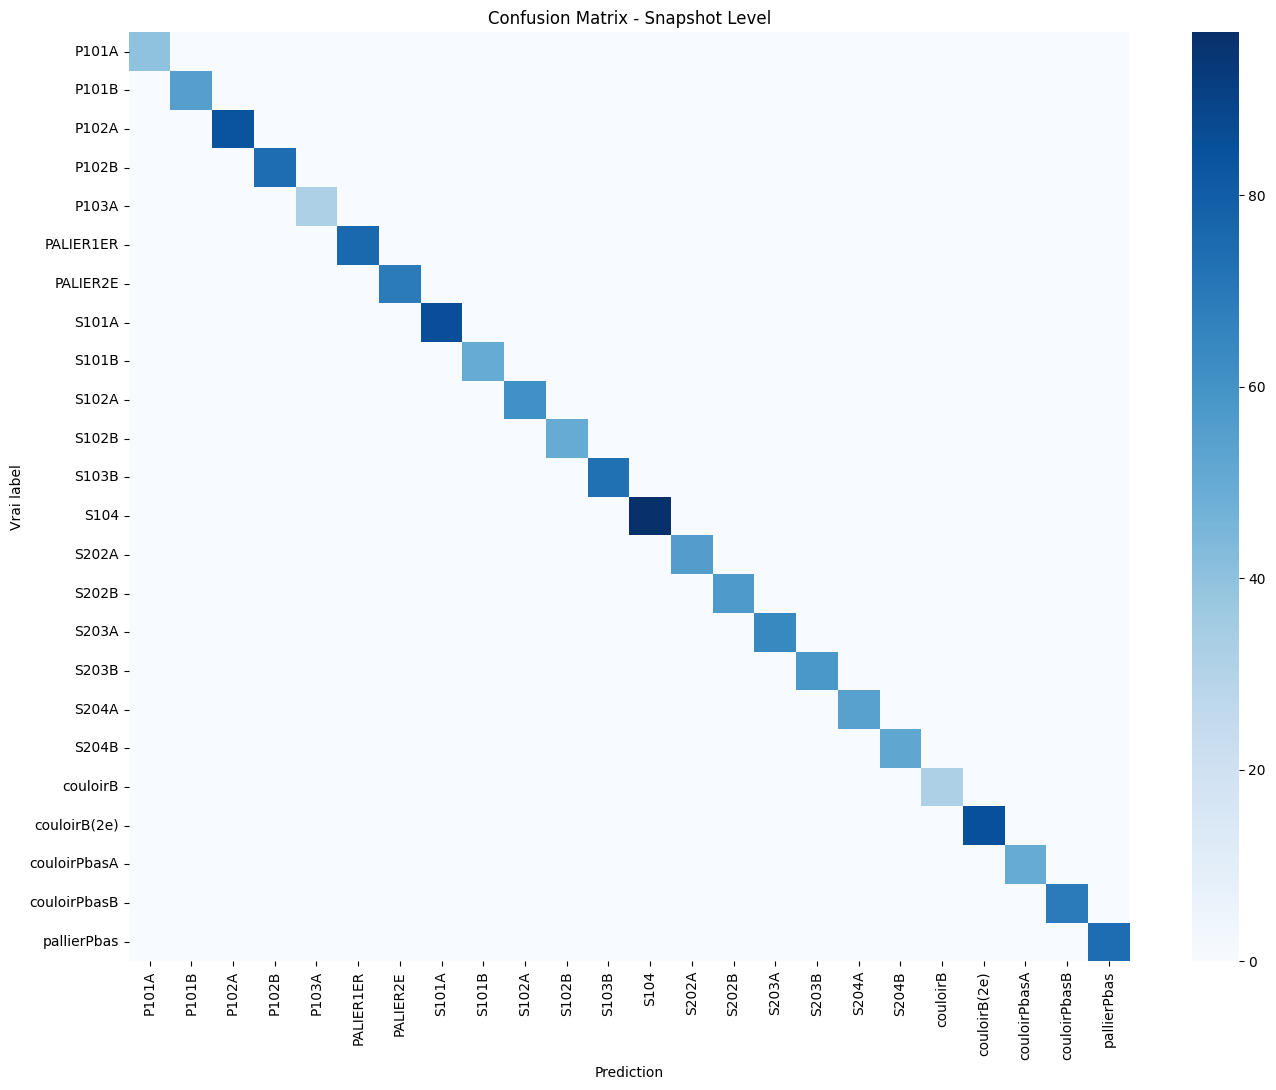

In [9]:
labels = sorted(y_true.unique().tolist())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Snapshot Level')
plt.xlabel('Prediction')
plt.ylabel('Vrai label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

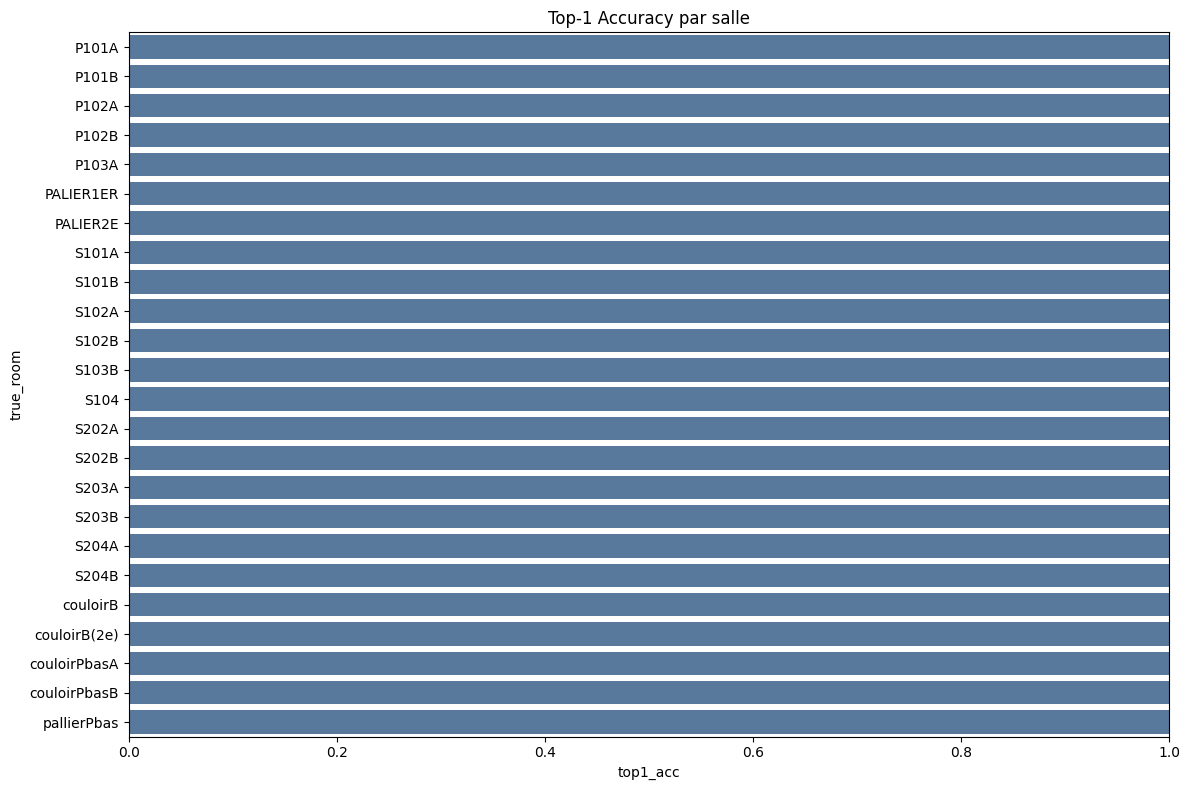

,true_room,n_snapshots,top1_acc,topk_acc,mean_confidence
0,P101A,40,1.0,1.0,0.885417
1,P101B,55,1.0,1.0,0.918788
2,P102A,84,1.0,1.0,0.902282
3,P102B,74,1.0,1.0,0.891667
4,P103A,32,1.0,1.0,0.980469
5,PALIER1ER,76,1.0,1.0,0.973684
6,PALIER2E,69,1.0,1.0,0.992995
7,S101A,86,1.0,1.0,0.959981
8,S101B,50,1.0,1.0,0.990667
9,S102A,61,1.0,1.0,0.971995


In [10]:
room_perf = (
    eval_df.groupby('true_room', as_index=False)
    .agg(
        n_snapshots=('predicted_room', 'size'),
        top1_acc=('is_correct', 'mean'),
        topk_acc=('topk_hit', 'mean'),
        mean_confidence=('confidence', 'mean')
    )
    .sort_values('top1_acc')
)
plt.figure(figsize=(12, 8))
sns.barplot(data=room_perf, x='top1_acc', y='true_room', color='#4C78A8')
plt.title('Top-1 Accuracy par salle')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()
display(room_perf)

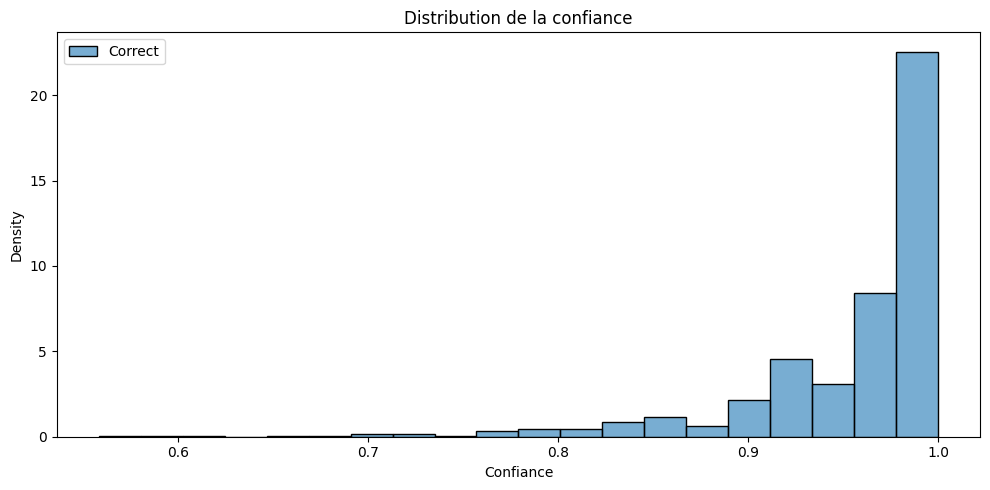

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(eval_df.loc[eval_df['is_correct'] == 1, 'confidence'], bins=20, stat='density', alpha=0.6, label='Correct')
sns.histplot(eval_df.loc[eval_df['is_correct'] == 0, 'confidence'], bins=20, stat='density', alpha=0.6, color='tomato', label='Incorrect')
plt.title('Distribution de la confiance')
plt.xlabel('Confiance')
plt.legend()
plt.tight_layout()
plt.show()

ECE: 0.0432


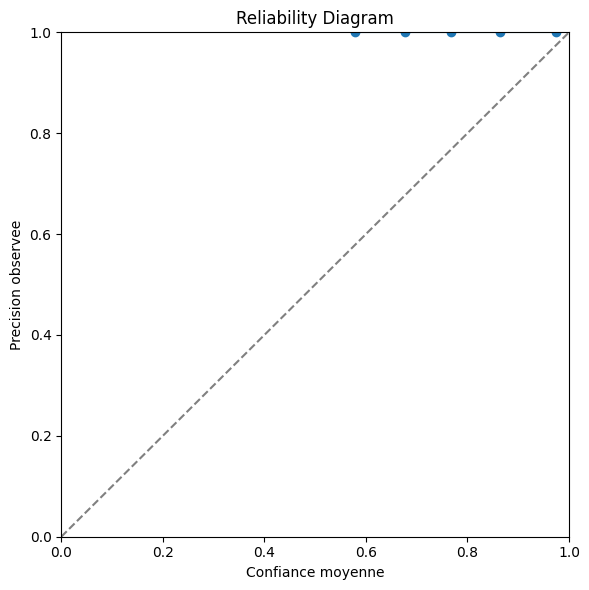

,n,accuracy,avg_confidence
bin,,,
"(0.5, 0.6]",2,1.0,0.579167
"(0.6, 0.7]",8,1.0,0.677083
"(0.7, 0.8]",37,1.0,0.767793
"(0.8, 0.9]",150,1.0,0.863833
"(0.9, 1.0]",1301,1.0,0.975199


In [12]:
bins = np.linspace(0, 1, 11)
calib = eval_df.copy()
calib['bin'] = pd.cut(calib['confidence'], bins=bins, include_lowest=True)
calib_tbl = (
    calib.groupby('bin', observed=False)
    .agg(
        n=('is_correct', 'size'),
        accuracy=('is_correct', 'mean'),
        avg_confidence=('confidence', 'mean')
    )
    .dropna()
)
ece = ((calib_tbl['n'] / calib_tbl['n'].sum()) * (calib_tbl['accuracy'] - calib_tbl['avg_confidence']).abs()).sum()
print(f'ECE: {ece:.4f}')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.plot(calib_tbl['avg_confidence'], calib_tbl['accuracy'], marker='o')
plt.title('Reliability Diagram')
plt.xlabel('Confiance moyenne')
plt.ylabel('Precision observee')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
display(calib_tbl)

## E. Interpretation de la confiance

- Score = probabilit? max de la salle pr?dite.
- Plus il est ?lev?, plus le mod?le est s?r de son choix.
- A calibrer avec ECE et la courbe de calibration pour valider la fiabilit? r?elle.
- En production, utiliser un seuil (ex. 0.8) + vote temporel am?liore la robustesse.